## 1. Mount Google Drive & Extract Dataset
We mount Google Drive to access the dataset zip file stored there.
The zip is extracted to /content/nonastreda — this only runs once.
If the folder already exists, extraction is skipped automatically.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.listdir('/content/drive/MyDrive'))

Mounted at /content/drive
['T-Shirt Sign Up.gform', 'Colab Notebooks', 'CT test 23070122091 Dhruv Gangurde.pdf', '8 Digital multimeter_0001.pdf', '23070122091 (Dhruv G) and  23070122169 (Pushkraj N).pptx', 'BEEE experiential learning Dhruv G 23070122091.pdf', 'Introduction.gdoc', 'Classroom', 'Final Review Project Report PBL 1 23-27 (1).gdoc', 'VedicConnect.zip', 'flowchart.drawio', 'Untitled presentation.gslides', 'nonastreda.zip.zip', 'nonastreda_checkpoints']


In [ ]:
import zipfile, os

zip_path    = "/content/drive/MyDrive/nonastreda.zip.zip"
extract_dir = "/content/nonastreda"

# Force fresh extraction
import shutil
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

os.makedirs(extract_dir, exist_ok=True)

print(f"Zip size: {os.path.getsize(zip_path)/1024/1024:.1f} MB")
print("Extracting...")

with zipfile.ZipFile(zip_path, 'r') as z:
    namelist = z.namelist()
    print(f"Files in zip: {len(namelist)}")
    print("First 5 entries:")
    for n in namelist[:5]:
        print(" ", n)
    z.extractall(extract_dir)

print("Done.")

# Find what got extracted
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    if level < 3:
        print(' ' * 2 * level + os.path.basename(root) + '/')

Zip size: 1336.2 MB
Extracting...
Files in zip: 4624
First 5 entries:
  Nonastreda Multimodal Dataset for Identifying Tool Wear Condition/
  Nonastreda Multimodal Dataset for Identifying Tool Wear Condition/Nonastreda Multimodal Dataset for Identifying Tool Wear Condition/
  Nonastreda Multimodal Dataset for Identifying Tool Wear Condition/Nonastreda Multimodal Dataset for Identifying Tool Wear Condition/chip/
  Nonastreda Multimodal Dataset for Identifying Tool Wear Condition/Nonastreda Multimodal Dataset for Identifying Tool Wear Condition/chip/T10R10B1.jpg
  Nonastreda Multimodal Dataset for Identifying Tool Wear Condition/Nonastreda Multimodal Dataset for Identifying Tool Wear Condition/chip/T10R10B2.jpg
Done.
nonastreda/
  Nonastreda Multimodal Dataset for Identifying Tool Wear Condition/
    Nonastreda Multimodal Dataset for Identifying Tool Wear Condition/


## 2. Imports & Device Setup
We import all required libraries — PyTorch for deep learning, torchvision
for pretrained models and transforms, PIL for image loading, and standard
utilities like numpy and pandas.

The device is set to GPU (cuda) if available, otherwise CPU.
A GPU is strongly recommended as each epoch takes ~60s on a T4 GPU.

In [ ]:

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Device: cuda
GPU: Tesla T4


## 3. Dataset Structure & Modality Paths
The Nonastreda dataset contains 9 visual modalities per sample:
- tool  : image of the cutting tool
- chip  : image of the chip produced during machining
- work  : image of the workpiece surface
- spec_x/y/z : spectrogram images from vibration sensors (3 axes)
- scal_x/y/z : scalogram images from vibration sensors (3 axes)

Each modality captures a different aspect of the machining process.
We verify all 9 modality folders exist before proceeding.

In [ ]:
DATASET_ROOT = Path("/content/nonastreda/Nonastreda Multimodal Dataset for Identifying Tool Wear Condition/Nonastreda Multimodal Dataset for Identifying Tool Wear Condition")

print("Dataset root:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

MODALITY_PATHS = {
    "tool":   DATASET_ROOT / "tool",
    "chip":   DATASET_ROOT / "chip",
    "work":   DATASET_ROOT / "work",
    "spec_x": DATASET_ROOT / "spec" / "x",
    "spec_y": DATASET_ROOT / "spec" / "y",
    "spec_z": DATASET_ROOT / "spec" / "z",
    "scal_x": DATASET_ROOT / "scal" / "x",
    "scal_y": DATASET_ROOT / "scal" / "y",
    "scal_z": DATASET_ROOT / "scal" / "z",
}

for name, path in MODALITY_PATHS.items():
    status = "✓" if path.exists() else "✗ MISSING"
    print(f"  [{status}]  {name}")


Dataset root: /content/nonastreda/Nonastreda Multimodal Dataset for Identifying Tool Wear Condition/Nonastreda Multimodal Dataset for Identifying Tool Wear Condition
Exists: True
  [✓]  tool
  [✓]  chip
  [✓]  work
  [✓]  spec_x
  [✓]  spec_y
  [✓]  spec_z
  [✓]  scal_x
  [✓]  scal_y
  [✓]  scal_z


## 4. Load & Merge Labels
Two CSV files are loaded:
- labels.csv     : classification labels (sharp / used / dulled)
- labels_reg.csv : regression targets (gaps, flank_wear, overhang in μm)

They are merged on the sample ID. The string class labels are mapped to
integers (sharp=0, used=1, dulled=2) for training. Tool ID is extracted
from the sample ID (e.g. T1, T2 ... T10) for cross-validation splitting.

In [ ]:
df_cls = pd.read_csv(DATASET_ROOT / "labels.csv")
df_reg = pd.read_csv(DATASET_ROOT / "labels_reg.csv")
df     = pd.merge(df_cls, df_reg, on="id", how="inner")

LABEL_MAP = {"sharp": 0, "used": 1, "dulled": 2}
df["label_int"] = df["image_label"].map(LABEL_MAP)
df["tool_id"]   = df["id"].str.extract(r"(T\d+)")

print(f"Dataset shape: {df.shape}")
print(f"Tools: {sorted(df['tool_id'].unique())}")
print(f"Classes: {df['image_label'].value_counts().to_dict()}")

Dataset shape: (512, 8)
Tools: ['T1', 'T10', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']
Classes: {'sharp': 197, 'used': 160, 'dulled': 155}


## 5. Resolve Image Paths
For each sample and each modality, we locate the actual image file on disk.
The function tries common extensions (.jpg, .png, .jpeg) and falls back to
positional indexing if no exact match is found.
Missing paths are reported — ideally all 512 samples × 9 modalities = 4608
paths should resolve successfully.

In [ ]:
def get_image_path(sample_id, modality_path, exts=[".jpg", ".png", ".jpeg"]):
    for ext in exts:
        p = modality_path / f"{sample_id}{ext}"
        if p.exists():
            return str(p)
    files = sorted(list(modality_path.glob("*.*")))
    if sample_id <= len(files):
        return str(files[sample_id - 1])
    return None

df_master = df.copy()
for modality, path in MODALITY_PATHS.items():
    df_master[f"path_{modality}"] = df_master["id"].apply(
        lambda sid: get_image_path(sid, path)
    )

print("Path resolution:")
for modality in MODALITY_PATHS:
    missing = df_master[f"path_{modality}"].isna().sum()
    print(f"  {modality:8s}  →  {512 - missing}/512  ({missing} missing)")

Path resolution:
  tool      →  512/512  (0 missing)
  chip      →  512/512  (0 missing)
  work      →  512/512  (0 missing)
  spec_x    →  512/512  (0 missing)
  spec_y    →  512/512  (0 missing)
  spec_z    →  512/512  (0 missing)
  scal_x    →  512/512  (0 missing)
  scal_y    →  512/512  (0 missing)
  scal_z    →  512/512  (0 missing)


## 6. Data Augmentation & Normalization
Training transforms apply random augmentations to improve generalization:
- Random horizontal/vertical flips
- Random rotation up to 20°
- Color jitter (brightness, contrast, saturation, hue)
- Random grayscale and affine translation
- Random erasing (simulates occlusion)

Validation transforms only resize and normalize — no augmentation,
so evaluation is deterministic.

Regression targets (gaps, flank_wear, overhang) are normalized using
dataset mean and std so the model learns on a consistent scale.
Note: reg_mean and reg_std are kept on CPU because DataLoader workers
cannot access CUDA memory.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=20),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    T.RandomGrayscale(p=0.1),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.2),
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

reg_cols = ["gaps", "flank_wear", "overhang"]

# Keep on CPU — DataLoader workers cannot access CUDA
reg_mean = torch.tensor(df_master[reg_cols].mean().values, dtype=torch.float32)
reg_std  = torch.tensor(df_master[reg_cols].std().values,  dtype=torch.float32)

print("Transforms and normalization ready.")
print(f"Reg mean: {reg_mean.numpy().round(2)}")
print(f"Reg std:  {reg_std.numpy().round(2)}")

Transforms and normalization ready.
Reg mean: [ 8.2  87.86 20.95]
Reg std:  [15.05 45.52 11.78]


7. Preload Images into RAM

    Reading 4608 images from Google Drive on every epoch is extremely slow (~60s/epoch). We solve this by loading all images into a Python dictionary in RAM once upfront. Subsequent epochs read from memory instead of disk, which is orders of magnitude faster. This requires ~2-4 GB of RAM depending on image sizes.

In [ ]:
from PIL import Image
import torchvision.transforms.functional as TF

print("Preloading all images into RAM...")
image_cache = {}

for modality, path in MODALITY_PATHS.items():
    for sid in df_master["id"]:
        key = (sid, modality)
        img_path = df_master.loc[df_master["id"] == sid, f"path_{modality}"].values[0]
        if img_path and key not in image_cache:
            image_cache[key] = Image.open(img_path).convert("RGB")

print(f"Cached {len(image_cache)} images into RAM.")

Preloading all images into RAM...
Cached 4608 images into RAM.


## 8. Custom PyTorch Dataset
The NonastredaDataset class handles loading all 9 modality images per sample.
For each sample it:
1. Loads all 9 images from the preloaded RAM cache (fast) or disk (slow)
2. Applies the transform to each image
3. Stacks them into a tensor of shape (9, C, H, W)
4. Returns the image stack, classification label, and normalized regression label

Using an image cache avoids repeated disk reads which are the main bottleneck
when data is stored on Google Drive.

In [ ]:
class NonastredaDataset(Dataset):
    def __init__(self, dataframe, modality_paths, transform=None,
                 reg_mean=None, reg_std=None, cache=None):
        self.df         = dataframe.reset_index(drop=True)
        self.modalities = list(modality_paths.keys())
        self.transform  = transform
        self.reg_mean   = reg_mean
        self.reg_std    = reg_std
        self.cache      = cache  # preloaded image dict

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        images = []
        for mod in self.modalities:
            if self.cache and (row["id"], mod) in self.cache:
                img = self.cache[(row["id"], mod)]  # load from RAM
            else:
                img = Image.open(row[f"path_{mod}"]).convert("RGB")
            if self.transform:
                img = self.transform(img)
            images.append(img)
        images = torch.stack(images, dim=0)

        cls_label = torch.tensor(row["label_int"], dtype=torch.long)
        reg_label = torch.tensor(
            [row["gaps"], row["flank_wear"], row["overhang"]],
            dtype=torch.float32
        )
        if self.reg_mean is not None and self.reg_std is not None:
            reg_label = (reg_label - self.reg_mean) / (self.reg_std + 1e-8)

        return images, cls_label, reg_label

print("Dataset class defined.")

Dataset class defined.


## 9. Model Architecture — MultimodalToolWearNet

The model has three components:

ModalityEncoder
  A shared MobileNetV2 backbone pretrained on ImageNet. All 9 modality images
  are processed in a single batched forward pass (B×9 images at once) for efficiency.
  The backbone is fully frozen — only the projection head is trainable.
  Output: feature vector of size 512 per modality.

GIRAPEFusion
  All 9 modality feature vectors (9×512 = 4608 dims) are concatenated and passed
  through a two-layer MLP with BatchNorm and Dropout to produce a fused
  representation of size 256.

Dual Heads
  - Classification head: predicts tool wear class (sharp / used / dulled)
  - Regression head: predicts wear measurements (gaps, flank_wear, overhang in μm)

This multi-task design forces the model to learn representations that are
useful for both coarse wear classification and fine-grained wear measurement.

In [ ]:
class ModalityEncoder(nn.Module):
    def __init__(self, out_features=512):
        super().__init__()
        base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        in_features = base.classifier[1].in_features
        base.classifier = nn.Identity()

        # Freeze all — fastest option
        for param in base.parameters():
            param.requires_grad = False

        self.backbone = base
        self.proj = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.BatchNorm1d(out_features),
            nn.ReLU(),
            nn.Dropout(0.5),
        )

    def forward(self, x):
        # x shape: (B, 9, C, H, W)
        B, M, C, H, W = x.shape
        # Merge batch and modality dims → process all 9 at once in one forward pass
        x = x.view(B * M, C, H, W)
        with torch.no_grad():
            feat = self.backbone(x)
        feat = self.proj(feat)
        return feat.view(B, M, -1)  # (B, 9, out_features)


class GIRAPEFusion(nn.Module):
    def __init__(self, num_modalities=9, modal_dim=512, fusion_dim=256):
        super().__init__()
        self.fusion = nn.Sequential(
            nn.Linear(num_modalities * modal_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, fusion_dim),
            nn.BatchNorm1d(fusion_dim),
            nn.ReLU(),
            nn.Dropout(0.4),
        )

    def forward(self, x):
        # x shape: (B, 9, modal_dim)
        B = x.shape[0]
        return self.fusion(x.view(B, -1))  # flatten modalities


class MultimodalToolWearNet(nn.Module):
    def __init__(self, num_classes=3, modal_dim=512, fusion_dim=256):
        super().__init__()
        self.encoder  = ModalityEncoder(out_features=modal_dim)
        self.fusion   = GIRAPEFusion(9, modal_dim, fusion_dim)
        self.cls_head = nn.Sequential(
            nn.Linear(fusion_dim, 64), nn.ReLU(), nn.Linear(64, num_classes)
        )
        self.reg_head = nn.Sequential(
            nn.Linear(fusion_dim, 64), nn.ReLU(), nn.Linear(64, 3)
        )

    def forward(self, x):
        feats = self.encoder(x)       # (B, 9, modal_dim)
        fused = self.fusion(feats)    # (B, fusion_dim)
        return self.cls_head(fused), self.reg_head(fused)

print("MobileNetV2 model classes defined.")

MobileNetV2 model classes defined.


## 10. Training Setup — T1 Held Out
We set up for a single training run with T1 as the held-out validation tool.
This is a preview before running full 10-fold cross-validation.

Key choices:
- Batch size 16 with num_workers=0 (cache makes workers unnecessary)
- Adam optimizer with lr=3e-4 and weight_decay=1e-4 (L2 regularization)
- CosineAnnealingLR scheduler — smoothly decays LR to near zero over 50 epochs
- Class-weighted CrossEntropyLoss to handle slight class imbalance
- Mixed precision training (AMP) on GPU for faster computation

In [ ]:
TEST_TOOL = "T1"
train_df  = df_master[df_master["tool_id"] != TEST_TOOL].reset_index(drop=True)
val_df    = df_master[df_master["tool_id"] == TEST_TOOL].reset_index(drop=True)

train_loader = DataLoader(
    NonastredaDataset(train_df, MODALITY_PATHS, train_transform, reg_mean, reg_std, cache=image_cache),
    batch_size=16, shuffle=True, num_workers=0, pin_memory=False
)
val_loader = DataLoader(
    NonastredaDataset(val_df, MODALITY_PATHS, val_transform, reg_mean, reg_std, cache=image_cache),
    batch_size=16, shuffle=False, num_workers=0, pin_memory=False
)

model = MultimodalToolWearNet().to(device)

total   = 512
weights = torch.tensor([total/197, total/160, total/155],
                        dtype=torch.float32).to(device)
cls_criterion = nn.CrossEntropyLoss(weight=weights)
reg_criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=50, eta_min=1e-6
)
scaler = torch.amp.GradScaler("cuda") if torch.cuda.is_available() else None

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 138MB/s]


Total params:     7,898,630
Trainable params: 5,674,758
Train batches: 30  |  Val batches: 3


## 11. Training Loop
The model is trained for 50 epochs. Each epoch:
1. Train pass  : forward pass → compute combined loss → backprop → update weights
2. Validate    : evaluate on T1 samples with no gradient computation
3. Checkpoint  : save model weights to Drive if val accuracy improves

Combined loss = CrossEntropy (classification) + 0.5 × MSE (regression)
The 0.5 weight balances the two tasks since MSE values tend to be larger.
Gradient clipping (max norm=1.0) prevents exploding gradients.

In [ ]:
import os, time

EPOCHS   = 50
SAVE_DIR = "/content/drive/MyDrive/nonastreda_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

best_acc = 0.0
history  = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"{'Epoch':>5}  {'T-Loss':>8}  {'V-Loss':>8}  {'T-Acc':>7}  {'V-Acc':>7}  {'Time':>6}")
print("-" * 52)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── Train ──
    model.train()
    t_loss = correct = total = 0
    for imgs, cls_lbl, reg_lbl in train_loader:
        imgs, cls_lbl, reg_lbl = imgs.to(device), cls_lbl.to(device), reg_lbl.to(device)
        optimizer.zero_grad()

        if scaler:
            with torch.amp.autocast("cuda"):
                cls_out, reg_out = model(imgs)
                loss = cls_criterion(cls_out, cls_lbl) + 0.5 * reg_criterion(reg_out, reg_lbl)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            cls_out, reg_out = model(imgs)
            loss = cls_criterion(cls_out, cls_lbl) + 0.5 * reg_criterion(reg_out, reg_lbl)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        t_loss  += loss.item()
        correct += (cls_out.argmax(1) == cls_lbl).sum().item()
        total   += cls_lbl.size(0)

    train_acc  = correct / total
    train_loss = t_loss / len(train_loader)

    # ── Validate ──
    model.eval()
    v_loss = v_correct = v_total = 0
    with torch.no_grad():
        for imgs, cls_lbl, reg_lbl in val_loader:
            imgs, cls_lbl, reg_lbl = imgs.to(device), cls_lbl.to(device), reg_lbl.to(device)
            if scaler:
                with torch.amp.autocast("cuda"):
                    cls_out, reg_out = model(imgs)
                    loss = cls_criterion(cls_out, cls_lbl) + 0.5 * reg_criterion(reg_out, reg_lbl)
            else:
                cls_out, reg_out = model(imgs)
                loss = cls_criterion(cls_out, cls_lbl) + 0.5 * reg_criterion(reg_out, reg_lbl)
            v_loss    += loss.item()
            v_correct += (cls_out.argmax(1) == cls_lbl).sum().item()
            v_total   += cls_lbl.size(0)

    val_acc  = v_correct / v_total
    val_loss = v_loss / len(val_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    saved = ""
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_acc": best_acc,
            "history": history
        }, f"{SAVE_DIR}/best_model_T1out.pth")
        saved = " ← saved"

    print(f"{epoch:>5}  {train_loss:>8.4f}  {val_loss:>8.4f}  "
          f"{train_acc:>7.3f}  {val_acc:>7.3f}  {time.time()-t0:>5.1f}s{saved}")

print(f"\nBest val accuracy: {best_acc:.3f}")
print(f"Saved to: {SAVE_DIR}")

Epoch    T-Loss    V-Loss    T-Acc    V-Acc    Time
----------------------------------------------------
    1    1.4277    0.9571    0.578    0.525   61.0s ← saved
    2    1.0442    0.6988    0.773    0.675   49.4s ← saved
    3    0.8482    0.5752    0.850    0.825   47.4s ← saved
    4    0.7967    0.5824    0.856    0.800   48.6s
    5    0.7555    0.5716    0.864    0.825   45.7s
    6    0.7118    0.5644    0.875    0.800   46.7s
    7    0.7119    0.5210    0.869    0.850   46.7s ← saved
    8    0.7615    0.4100    0.867    0.900   46.7s ← saved
    9    0.6994    0.5657    0.864    0.800   48.3s
   10    0.7109    0.4266    0.873    0.925   46.7s ← saved
   11    0.6744    0.3565    0.869    0.950   49.3s ← saved
   12    0.7011    0.4513    0.890    0.850   46.2s
   13    0.6352    0.3680    0.892    0.975   45.8s ← saved
   14    0.6658    0.3211    0.881    0.975   47.6s
   15    0.6598    0.5015    0.879    0.850   45.4s
   16    0.6679    0.4250    0.888    0.850   45.5s

## 12. Training Curves
We plot loss and accuracy over all 50 epochs for both train and validation sets.
A well-trained model should show:
- Both losses decreasing and converging
- Val accuracy close to train accuracy (no overfitting)
- The best val accuracy marked with a dashed line

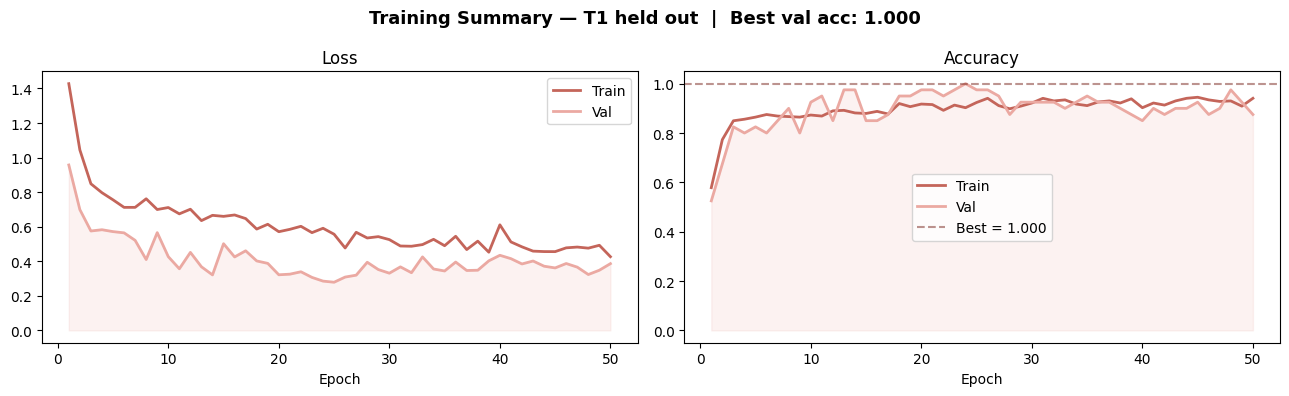

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"Training Summary — T1 held out  |  Best val acc: {best_acc:.3f}",
             fontweight="bold", fontsize=13)

epochs_x = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_x, history["train_loss"], color="#C4655A", label="Train", linewidth=2)
axes[0].plot(epochs_x, history["val_loss"],   color="#EBA9A2", label="Val",   linewidth=2)
axes[0].fill_between(epochs_x, history["val_loss"], alpha=0.15, color="#EBA9A2")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_x, history["train_acc"], color="#C4655A", label="Train", linewidth=2)
axes[1].plot(epochs_x, history["val_acc"],   color="#EBA9A2", label="Val",   linewidth=2)
axes[1].fill_between(epochs_x, history["val_acc"], alpha=0.15, color="#EBA9A2")
axes[1].axhline(best_acc, color="#7A2820", linestyle="--", alpha=0.5,
                label=f"Best = {best_acc:.3f}")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_curves_T1out.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Load Best Model & Run Predictions
We reload the best checkpoint saved during training (highest val accuracy epoch)
and run a full inference pass on the T1 validation set.
Regression outputs are denormalized back to original μm scale for interpretability.

In [ ]:
checkpoint = torch.load(f"{SAVE_DIR}/best_model_T1out.pth", map_location=device)
model.load_state_dict(checkpoint["model_state"])
print(f"Loaded epoch {checkpoint['epoch']}  |  val_acc = {checkpoint['best_acc']:.4f}")

model.eval()
all_cls_true = []
all_cls_pred = []
all_reg_true = []
all_reg_pred = []

with torch.no_grad():
    for imgs, cls_lbl, reg_lbl in val_loader:
        imgs = imgs.to(device)
        cls_out, reg_out = model(imgs)
        all_cls_true.extend(cls_lbl.numpy())
        all_cls_pred.extend(cls_out.argmax(1).cpu().numpy())
        reg_pred_denorm = reg_out.cpu() * reg_std + reg_mean
        reg_true_denorm = reg_lbl       * reg_std + reg_mean
        all_reg_true.extend(reg_true_denorm.numpy())
        all_reg_pred.extend(reg_pred_denorm.numpy())

all_cls_true = np.array(all_cls_true)
all_cls_pred = np.array(all_cls_pred)
all_reg_true = np.array(all_reg_true)
all_reg_pred = np.array(all_reg_pred)

print("Predictions ready.")

Loaded epoch 24  |  val_acc = 1.0000
Predictions ready.


## 14. Classification Results
We evaluate the model's wear classification performance using:
- Precision, Recall, F1-score per class
- Overall accuracy
- Confusion matrix showing which classes are confused with each other

A perfect model would have a diagonal confusion matrix with all samples
correctly classified.

  CLASSIFICATION RESULTS — T1 HELD OUT
              precision    recall  f1-score   support

       sharp       1.00      1.00      1.00        14
        used       1.00      1.00      1.00        16
      dulled       1.00      1.00      1.00        10

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



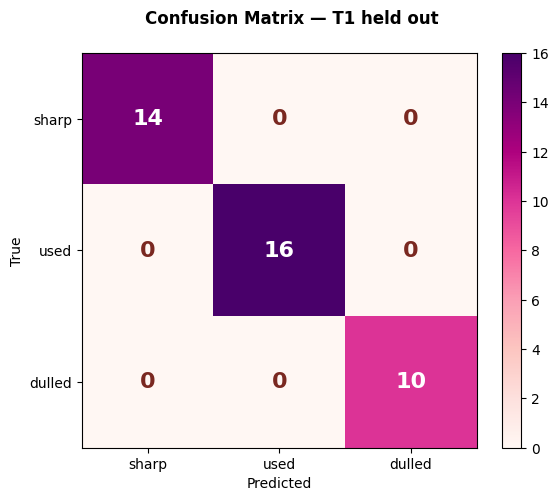

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("=" * 50)
print("  CLASSIFICATION RESULTS — T1 HELD OUT")
print("=" * 50)
print(classification_report(all_cls_true, all_cls_pred,
      target_names=["sharp", "used", "dulled"]))

cm     = confusion_matrix(all_cls_true, all_cls_pred)
labels = ["sharp", "used", "dulled"]

fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle("Confusion Matrix — T1 held out", fontweight="bold")

im = ax.imshow(cm, cmap="RdPu")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=16,
                fontweight="bold",
                color="white" if cm[i, j] > cm.max() / 2 else "#7A2820")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrix_T1out.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Regression Results
We evaluate the wear measurement predictions using three metrics per target:
- MAE  (Mean Absolute Error)  : average prediction error in μm
- RMSE (Root Mean Squared Error) : penalizes large errors more heavily
- R²   (Coefficient of Determination) : 1.0 = perfect, 0.0 = predicts mean only

Scatter plots show true vs predicted values — points on the diagonal dashed
line represent perfect predictions.

  REGRESSION RESULTS — T1 HELD OUT
        Target       MAE      RMSE        R²
  ──────────────────────────────────────────
          gaps     5.676     7.072    -0.055
    flank_wear     9.826    12.294     0.831
      overhang     7.812    10.302    -0.059


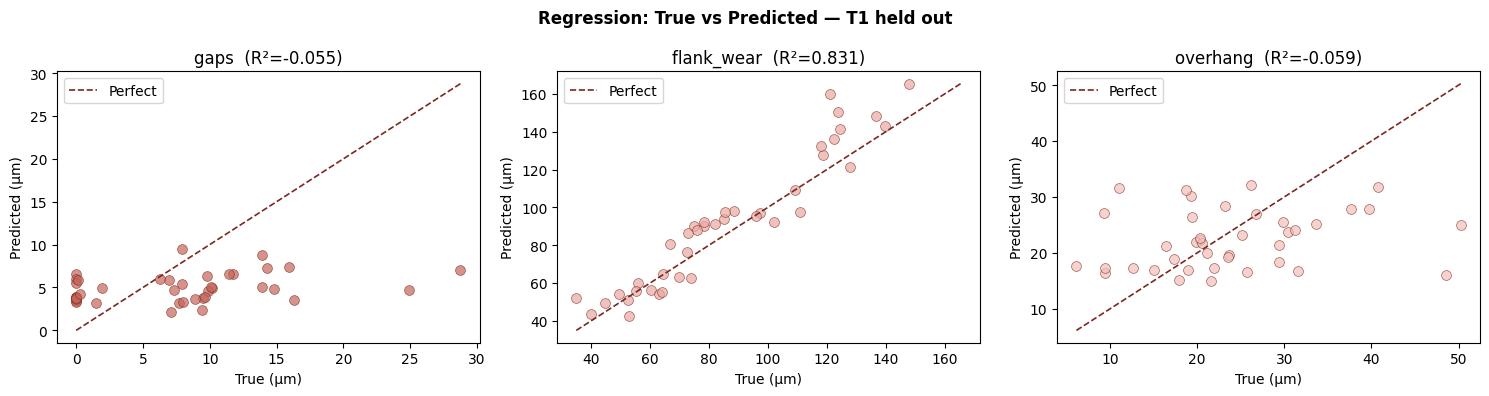

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

reg_targets = ["gaps", "flank_wear", "overhang"]

print("=" * 48)
print("  REGRESSION RESULTS — T1 HELD OUT")
print("=" * 48)
print(f"  {'Target':>12}  {'MAE':>8}  {'RMSE':>8}  {'R²':>8}")
print("  " + "─" * 42)

for i, target in enumerate(reg_targets):
    true = all_reg_true[:, i]
    pred = all_reg_pred[:, i]
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2   = 1 - np.sum((true-pred)**2) / (np.sum((true-true.mean())**2) + 1e-8)
    print(f"  {target:>12}  {mae:>8.3f}  {rmse:>8.3f}  {r2:>8.3f}")

print("=" * 48)

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Regression: True vs Predicted — T1 held out", fontweight="bold")
colors = ["#C4655A", "#EBA9A2", "#F3C0BA"]

for i, (target, color) in enumerate(zip(reg_targets, colors)):
    true = all_reg_true[:, i]
    pred = all_reg_pred[:, i]
    mn, mx = min(true.min(), pred.min()), max(true.max(), pred.max())

    axes[i].scatter(true, pred, alpha=0.7, color=color,
                    edgecolors="#7A2820", s=50, linewidths=0.5)
    axes[i].plot([mn, mx], [mn, mx], "--", color="#7A2820",
                 linewidth=1.2, label="Perfect")
    r2 = 1 - np.sum((true-pred)**2) / (np.sum((true-true.mean())**2) + 1e-8)
    axes[i].set_title(f"{target}  (R²={r2:.3f})")
    axes[i].set_xlabel(f"True (μm)"); axes[i].set_ylabel(f"Predicted (μm)")
    axes[i].legend()

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/regression_scatter_T1out.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. 10-Fold Leave-One-Tool-Out Cross Validation
The single T1 fold above only tells us how well the model generalizes to one tool.
To get a robust estimate across all tools, we run 10-fold cross-validation where
each tool is held out once as the test set.

This is the most rigorous evaluation for this dataset because:
- Each tool has unique wear patterns and cutting conditions
- A model that only works on some tools is not practically useful
- The mean accuracy across all 10 folds is the final reported performance

Progress is saved to Drive after every fold — if the session disconnects,
re-running this cell will automatically resume from the last completed fold.

In [ ]:
import os, time
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error

all_tools    = sorted(df_master["tool_id"].unique())
results_path = f"{SAVE_DIR}/cv_results.csv"

if os.path.exists(results_path):
    df_existing  = pd.read_csv(results_path)
    fold_results = df_existing.to_dict("records")
    done_tools   = set(df_existing["test_tool"].tolist())
    print(f"Resuming — already done: {sorted(done_tools)}")
else:
    fold_results = []
    done_tools   = set()

print(f"\nRunning {len(all_tools)}-fold leave-one-tool-out CV")
print(f"{'Fold':>5}  {'Tool':>6}  {'Val Acc':>8}  {'Best Ep':>8}  {'Time':>8}")
print("─" * 42)

best_overall_acc   = 0.0
best_overall_tool  = None
best_overall_state = None

for fold, test_tool in enumerate(all_tools, 1):
    if test_tool in done_tools:
        print(f"{fold:>5}  {test_tool:>6}  skipped ✓")
        continue

    t_fold = time.time()
    tr_df  = df_master[df_master["tool_id"] != test_tool].reset_index(drop=True)
    vl_df  = df_master[df_master["tool_id"] == test_tool].reset_index(drop=True)

    tr_loader = DataLoader(
        NonastredaDataset(tr_df, MODALITY_PATHS, train_transform,
                          reg_mean, reg_std, cache=image_cache),
        batch_size=16, shuffle=True, num_workers=0
    )
    vl_loader = DataLoader(
        NonastredaDataset(vl_df, MODALITY_PATHS, val_transform,
                          reg_mean, reg_std, cache=image_cache),
        batch_size=16, shuffle=False, num_workers=0
    )

    fold_model  = MultimodalToolWearNet().to(device)
    fold_optim  = torch.optim.Adam(
        filter(lambda p: p.requires_grad, fold_model.parameters()),
        lr=3e-4, weight_decay=1e-4
    )
    fold_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(fold_optim, T_max=30, eta_min=1e-6)
    fold_scaler = torch.amp.GradScaler("cuda") if torch.cuda.is_available() else None

    best_fold_acc = 0.0
    best_epoch    = 0

    for epoch in range(1, 21):
        fold_model.train()
        for imgs, cls_lbl, reg_lbl in tr_loader:
            imgs, cls_lbl, reg_lbl = imgs.to(device), cls_lbl.to(device), reg_lbl.to(device)
            fold_optim.zero_grad()
            if fold_scaler:
                with torch.amp.autocast("cuda"):
                    cls_out, reg_out = fold_model(imgs)
                    loss = cls_criterion(cls_out, cls_lbl) + 0.5 * reg_criterion(reg_out, reg_lbl)
                fold_scaler.scale(loss).backward()
                fold_scaler.unscale_(fold_optim)
                torch.nn.utils.clip_grad_norm_(fold_model.parameters(), 1.0)
                fold_scaler.step(fold_optim)
                fold_scaler.update()
            else:
                cls_out, reg_out = fold_model(imgs)
                loss = cls_criterion(cls_out, cls_lbl) + 0.5 * reg_criterion(reg_out, reg_lbl)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(fold_model.parameters(), 1.0)
                fold_optim.step()
        fold_sched.step()

        fold_model.eval()
        correct = total = 0
        all_rt, all_rp = [], []
        with torch.no_grad():
            for imgs, cls_lbl, reg_lbl in vl_loader:
                imgs, cls_lbl, reg_lbl = imgs.to(device), cls_lbl.to(device), reg_lbl.to(device)
                cls_out, reg_out = fold_model(imgs)
                correct += (cls_out.argmax(1) == cls_lbl).sum().item()
                total   += cls_lbl.size(0)
                all_rt.append((reg_lbl.cpu() * reg_std + reg_mean).numpy())
                all_rp.append((reg_out.cpu() * reg_std + reg_mean).numpy())

        val_acc = correct / total
        if val_acc > best_fold_acc:
            best_fold_acc = val_acc
            best_epoch    = epoch
            # Save per-fold best as before
            torch.save(fold_model.state_dict(),
                       f"{SAVE_DIR}/best_model_{test_tool}out.pth")
            best_rt = np.vstack(all_rt)
            best_rp = np.vstack(all_rp)

            # Track overall best across all folds
            if val_acc > best_overall_acc:
                best_overall_acc   = val_acc
                best_overall_tool  = test_tool
                best_overall_state = fold_model.state_dict().copy()

    fold_mae  = [mean_absolute_error(best_rt[:, i], best_rp[:, i]) for i in range(3)]
    fold_rmse = [np.sqrt(mean_squared_error(best_rt[:, i], best_rp[:, i])) for i in range(3)]

    fold_results.append({
        "fold": fold, "test_tool": test_tool,
        "val_acc": best_fold_acc, "best_epoch": best_epoch,
        "mae_gaps": fold_mae[0], "mae_flank": fold_mae[1], "mae_overhang": fold_mae[2],
        "rmse_gaps": fold_rmse[0], "rmse_flank": fold_rmse[1], "rmse_overhang": fold_rmse[2],
    })

    pd.DataFrame(fold_results).to_csv(results_path, index=False)
    elapsed = time.time() - t_fold
    marker  = " 🏆" if best_fold_acc == 1.0 else (" ✓" if best_fold_acc >= 0.9 else "")
    print(f"{fold:>5}  {test_tool:>6}  {best_fold_acc:>8.3f}  {best_epoch:>8}  {elapsed:>7.0f}s{marker}")

# ── Save best overall model after all folds complete ──
if best_overall_state is not None:
    torch.save({
        "model_state":  best_overall_state,
        "best_acc":     best_overall_acc,
        "best_tool":    best_overall_tool,
        "fold_results": fold_results,
    }, f"{SAVE_DIR}/best_model_overall.pth")
    print(f"\n🏆 Best overall model: {best_overall_tool} held out  |  acc = {best_overall_acc:.3f}")

print(f"\nAll folds complete. Results saved to Drive.")

Resuming — already done: ['T1', 'T10', 'T2', 'T3', 'T4']

Running 10-fold leave-one-tool-out CV
 Fold    Tool   Val Acc   Best Ep      Time
──────────────────────────────────────────
    1      T1  skipped ✓
    2     T10  skipped ✓
    3      T2  skipped ✓
    4      T3  skipped ✓
    5      T4  skipped ✓
    6      T5     0.938        11      935s ✓
    7      T6     0.900        19      931s ✓
    8      T7     1.000        18      913s 🏆
    9      T8     0.942        12      897s ✓
   10      T9     0.962         6      912s ✓

🏆 Best overall model: T7 held out  |  acc = 1.000

All folds complete. Results saved to Drive.


## 17. Cross-Validation Summary
We load the saved CV results and summarize performance across all 10 folds.
The bar charts show per-fold accuracy and MAE so we can identify which tools
are harder to generalize to and where the model struggles most.

  CROSS-VALIDATION RESULTS — LEAVE-ONE-TOOL-OUT


,fold,test_tool,val_acc,best_epoch,mae_gaps,mae_flank,mae_overhang
0,1,T1,0.950,16,5.340,7.834,7.854
1,2,T10,0.982,10,9.590,17.544,8.468
2,3,T2,0.982,6,6.356,14.574,10.239
3,4,T3,0.865,12,6.332,12.665,10.862
4,5,T4,0.975,11,4.822,17.774,6.833
5,6,T5,0.938,11,5.610,35.640,10.312
6,7,T6,0.900,19,5.880,17.826,7.856
7,8,T7,1.000,18,3.675,12.792,6.668
8,9,T8,0.942,12,15.492,13.244,7.118
9,10,T9,0.962,6,5.414,11.904,5.516



  Mean ± Std across all folds:
  Accuracy       0.950 ± 0.041
  MAE gaps       6.851 ± 3.395 μm
  MAE flank      16.180 ± 7.519 μm
  MAE overhang   8.172 ± 1.782 μm


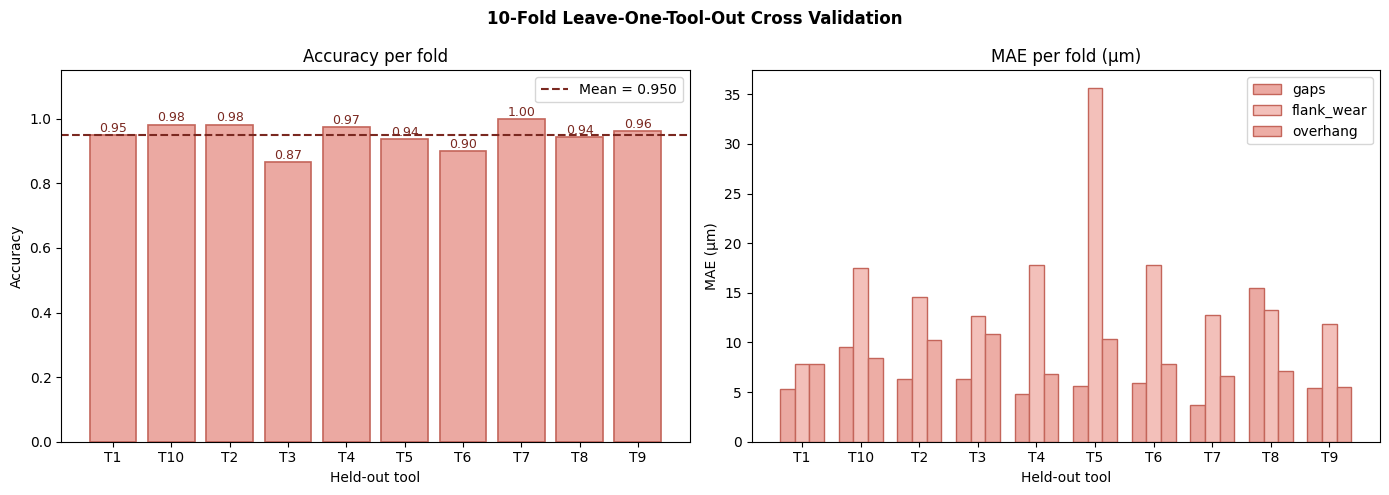

In [ ]:
df_results = pd.read_csv(results_path)

print("=" * 60)
print("  CROSS-VALIDATION RESULTS — LEAVE-ONE-TOOL-OUT")
print("=" * 60)
display(df_results[["fold","test_tool","val_acc","best_epoch",
                     "mae_gaps","mae_flank","mae_overhang"]].round(3))

print("\n  Mean ± Std across all folds:")
print(f"  {'Accuracy':<14} {df_results['val_acc'].mean():.3f} ± {df_results['val_acc'].std():.3f}")
print(f"  {'MAE gaps':<14} {df_results['mae_gaps'].mean():.3f} ± {df_results['mae_gaps'].std():.3f} μm")
print(f"  {'MAE flank':<14} {df_results['mae_flank'].mean():.3f} ± {df_results['mae_flank'].std():.3f} μm")
print(f"  {'MAE overhang':<14} {df_results['mae_overhang'].mean():.3f} ± {df_results['mae_overhang'].std():.3f} μm")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("10-Fold Leave-One-Tool-Out Cross Validation", fontweight="bold")

# Accuracy per fold
bars = axes[0].bar(df_results["test_tool"], df_results["val_acc"],
                   color="#EBA9A2", edgecolor="#C4655A", linewidth=1.2)
axes[0].axhline(df_results["val_acc"].mean(), color="#7A2820",
                linestyle="--", linewidth=1.5,
                label=f"Mean = {df_results['val_acc'].mean():.3f}")
for bar, val in zip(bars, df_results["val_acc"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", fontsize=9, color="#7A2820")
axes[0].set_title("Accuracy per fold")
axes[0].set_xlabel("Held-out tool")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.15)
axes[0].legend()

# MAE per fold
x = np.arange(len(df_results))
w = 0.25
axes[1].bar(x - w, df_results["mae_gaps"],     w, label="gaps",      color="#EBA9A2", edgecolor="#C4655A")
axes[1].bar(x,     df_results["mae_flank"],    w, label="flank_wear", color="#F3C0BA", edgecolor="#C4655A")
axes[1].bar(x + w, df_results["mae_overhang"], w, label="overhang",   color="#EDADA5", edgecolor="#C4655A")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_results["test_tool"])
axes[1].set_title("MAE per fold (μm)")
axes[1].set_xlabel("Held-out tool")
axes[1].set_ylabel("MAE (μm)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cv_summary.png", dpi=150, bbox_inches="tight")
plt.show()